# **Métodos de búsqueda**
### Julieta Madrigal 744029
### Lunes 23 de marzo 2026

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.pipeline import Pipeline

In [61]:
np.random.seed(42)

# Generamos los datos de entrenamiento = Valores iniciales
X_train = np.array([2, 3, 7,9.9963,10,12]).reshape(-1, 1)
y_train = np.array([-4017, -1255, 1773, 2847.31363, 2847,563]).reshape(-1, 1)


In [62]:
modelo = Pipeline([
    ('gp', GaussianProcessRegressor(random_state=42,))])

modelo.fit(X_train, y_train)

Pipeline(steps=[('gp', GaussianProcessRegressor(random_state=42))])

In [63]:
# Creamos un vector de valores posibles de X y predecimos Y

# 10,001 puntos
# que vayan del 2 al 15
# debe de ser del mismo tamaño que la otra X_train
# np.linespace te da los pasos equitativos
X_sim = np.linspace(2, 15, 10001).reshape(-1, 1)

# return_std = True me da la desviación estándar
y_sim, y_sim_std = modelo.predict(X_sim, return_std=True)

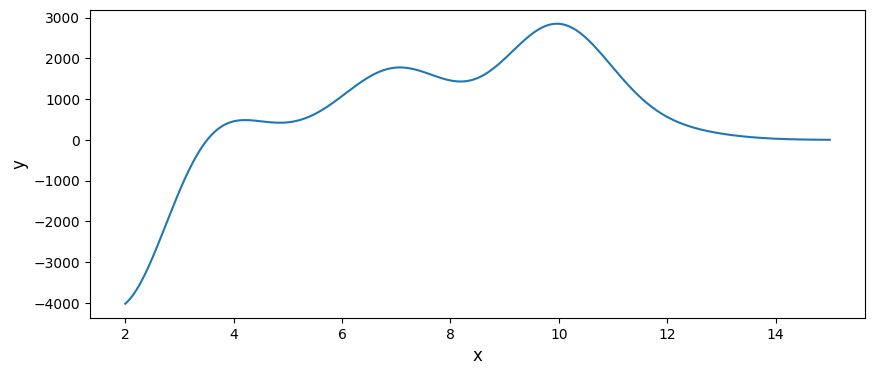

In [64]:
plt.figure(figsize=(10, 4))
plt.plot(X_sim, y_sim)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.show()

## Intervalo de confianza al 95% = 2 desviaciones estandar

In [65]:
# y_sim +/- y_sim_std

intervalo_inferior = y_sim - (2*y_sim_std)
intervalo_superior  = y_sim + (2*y_sim)

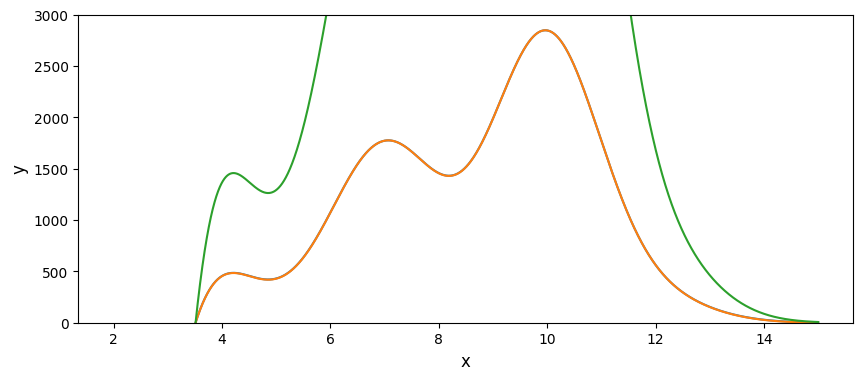

In [66]:
plt.figure(figsize=(10, 4))
plt.plot(X_sim, y_sim)
plt.plot(X_sim, intervalo_inferior)
plt.plot(X_sim, intervalo_superior)


plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.ylim(0,3000)
plt.show()

## Encontrar el punto máximo

In [67]:
idx_max = np.argmax(intervalo_superior)
x_max = X_sim[idx_max][0]
x_max
# es el punto x de mi intervalo superior más alto

np.float64(9.9651)

# **NOTAAAAA**
Cada que agregas un punto, el modelo se debe de entrenar = TODO SE DEBE DE REPETIR



In [68]:
x_nuevo =np.array([9.9651]).reshape(-1,1)
y_nuevo =np.array([2849.5981]).reshape(-1, 1)

In [69]:
X_train =np.vstack((X_train, x_nuevo))
y_train = np.vstack((y_train, y_nuevo))

In [70]:
modelo = Pipeline([
    ('gp', GaussianProcessRegressor(random_state=42,))])

modelo.fit(X_train, y_train)

Pipeline(steps=[('gp', GaussianProcessRegressor(random_state=42))])

In [71]:
# Creamos un vector de valores posibles de X y predecimos Y

X_sim = np.linspace(2, 15, 10001).reshape(-1, 1)

# return_std = True me da la desviación estándar
y_sim, y_sim_std = modelo.predict(X_sim, return_std=True)

In [72]:
intervalo_inferior = y_sim - (2*y_sim_std)
intervalo_superior  = y_sim + (2*y_sim)

In [73]:
idx_max = np.argmax(intervalo_superior)
x_max = X_sim[idx_max][0]
x_max

np.float64(9.874099999999999)

### Agregamos OTRO dato

In [74]:
# nuevos datos
x_nuevo =np.array([9.8741]).reshape(-1,1)
y_nuevo =np.array([2852.69711]).reshape(-1, 1)

# actualizamos los datos de entrenamiento
X_train =np.vstack((X_train, x_nuevo))
y_train = np.vstack((y_train, y_nuevo))

# Modelo
modelo = Pipeline([
    ('gp', GaussianProcessRegressor(random_state=42,))])

modelo.fit(X_train, y_train)

# Creamos un vector de valores posibles de X y predecimos Y
X_sim = np.linspace(2, 15, 10001).reshape(-1, 1)

# return_std = True me da la desviación estándar
y_sim, y_sim_std = modelo.predict(X_sim, return_std=True)

# Intervalos de confianza
intervalo_inferior = y_sim - (2*y_sim_std)
intervalo_superior  = y_sim + (2*y_sim)


# Identificamos el máximo
idx_max = np.argmax(intervalo_superior)
x_max = X_sim[idx_max][0]

# Punto máximo
x_max

np.float64(9.8637)

# **Conclusión**

En esta clase empezamos con 3 valores iniciales, los entrenamos y a partir de eso generamos un vector de valores simulados que estén en el mismo formato que la X inicial. Después se obtiene la y_simulada  y la desviación estándar de la y_simulada a partir de la X simulada. Posteriormente se crea el intervalo de confianza al 95% = 2 desviaciones estándar, para definir el intervalo superior a la y_simulada se le suman DOS VECES la desviación estándar; mientras que para definir el intervalo inferior se le resta DOS VECES la desviación estándar a la y_simulada. Finalmente, identificamos el máximo utilizando el comando np.argmax, se guarda en un índice y tomas la primera posición para obtener verdadero máximo. Se toma ese nuevo valor de X y se agrega a la X_train para repetir todo el proceso y obtener nuevamente otro valor.

Este proceso nos permite seguir nutriendo o mejorando el modelo al irle agregando información y que cada predicción sea mejor que la anterior.